# Interactive Three-Phase Power System Analysis
## With Sequence Components, Clarke & Park Transforms

This notebook provides interactive sliders to explore:
- Positive and negative sequence currents
- Park transform offset angle
- Gaussian envelope parameters
- All three reference frames: ABC, Clarke (αβ0), and Park (dq0)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets

# Set default plot style
plt.rcParams['figure.figsize'] = (16, 22)
plt.rcParams['font.size'] = 10

## Main Interactive Plot Function

In [4]:
def plot_three_phase_system(
    I_pos_mag=200,      # Positive sequence magnitude (A, peak)
    I_pos_angle=20,     # Positive sequence angle (degrees)
    I_neg_mag=130,      # Negative sequence magnitude (A, peak)
    I_neg_angle=-23,    # Negative sequence angle (degrees)
    park_offset=15,     # Park transform offset (degrees)
    gauss_center=3.25,  # Gaussian center (cycles)
    gauss_width=0.5     # Gaussian width (cycles)
):
    """
    Interactive three-phase power system visualization
    """
    
    # Fixed parameters
    V_LL_rms = 480
    V_LN_rms = V_LL_rms / np.sqrt(3)
    V_LN_peak = V_LN_rms * np.sqrt(2)
    V_LL_peak = V_LL_rms * np.sqrt(2)
    
    f = 60
    omega = 2 * np.pi * f
    T = 1/f
    cycles = 5
    t_end = cycles * T
    
    # Convert angles to radians
    I_pos_angle_rad = I_pos_angle * np.pi / 180
    I_neg_angle_rad = I_neg_angle * np.pi / 180
    park_offset_rad = park_offset * np.pi / 180
    
    # Time array
    fs = 10000
    t = np.linspace(0, t_end, int(fs * t_end))
    
    # Three-phase voltages (line-to-neutral)
    V_a = V_LN_peak * np.sin(2 * np.pi * f * t)
    V_b = V_LN_peak * np.sin(2 * np.pi * f * t - 2*np.pi/3)
    V_c = V_LN_peak * np.sin(2 * np.pi * f * t + 2*np.pi/3)
    
    # Line-to-line voltages
    V_ab = V_a - V_b
    V_bc = V_b - V_c
    V_ca = V_c - V_a
    
    # Gaussian envelope
    t_pulse_center = gauss_center * T
    sigma = gauss_width * T / 4
    gaussian_envelope = np.exp(-((t - t_pulse_center)**2) / (2 * sigma**2))
    
    # Positive sequence currents
    I_pos_a = I_pos_mag * np.sin(omega * t + I_pos_angle_rad)
    I_pos_b = I_pos_mag * np.sin(omega * t + I_pos_angle_rad - 2*np.pi/3)
    I_pos_c = I_pos_mag * np.sin(omega * t + I_pos_angle_rad + 2*np.pi/3)
    
    # Negative sequence currents
    I_neg_a = I_neg_mag * np.sin(omega * t + I_neg_angle_rad)
    I_neg_b = I_neg_mag * np.sin(omega * t + I_neg_angle_rad + 2*np.pi/3)
    I_neg_c = I_neg_mag * np.sin(omega * t + I_neg_angle_rad - 2*np.pi/3)
    
    # Total currents
    I_a = (I_pos_a + I_neg_a) * gaussian_envelope
    I_b = (I_pos_b + I_neg_b) * gaussian_envelope
    I_c = (I_pos_c + I_neg_c) * gaussian_envelope
    
    # Power calculations
    p_a = V_a * I_a
    p_b = V_b * I_b
    p_c = V_c * I_c
    p_total = p_a + p_b + p_c
    
    p_ab = V_ab * I_a
    p_bc = V_bc * I_b
    p_ca = V_ca * I_c
    p_total_ll = p_ab + p_bc + p_ca
    
    # Clarke transformation
    T_clarke = np.sqrt(2/3) * np.array([
        [1, -1/2, -1/2],
        [0, np.sqrt(3)/2, -np.sqrt(3)/2],
        [1/np.sqrt(2), 1/np.sqrt(2), 1/np.sqrt(2)]
    ])
    
    V_alpha = T_clarke[0, 0] * V_a + T_clarke[0, 1] * V_b + T_clarke[0, 2] * V_c
    V_beta = T_clarke[1, 0] * V_a + T_clarke[1, 1] * V_b + T_clarke[1, 2] * V_c
    V_zero = T_clarke[2, 0] * V_a + T_clarke[2, 1] * V_b + T_clarke[2, 2] * V_c
    
    I_alpha = T_clarke[0, 0] * I_a + T_clarke[0, 1] * I_b + T_clarke[0, 2] * I_c
    I_beta = T_clarke[1, 0] * I_a + T_clarke[1, 1] * I_b + T_clarke[1, 2] * I_c
    I_zero = T_clarke[2, 0] * I_a + T_clarke[2, 1] * I_b + T_clarke[2, 2] * I_c
    
    # Park transformation with offset
    theta = omega * t + park_offset_rad
    
    V_d = V_alpha * np.cos(theta) + V_beta * np.sin(theta)
    V_q = -V_alpha * np.sin(theta) + V_beta * np.cos(theta)
    V_0_park = V_zero
    
    I_d = I_alpha * np.cos(theta) + I_beta * np.sin(theta)
    I_q = -I_alpha * np.sin(theta) + I_beta * np.cos(theta)
    I_0_park = I_zero
    
    # Zoom window
    t_zoom_start = 1.5 * T
    t_zoom_end = 5.5 * T
    
    # Create plots
    fig = plt.figure(figsize=(16, 26))
    gs = fig.add_gridspec(6, 1, hspace=0.3)
    ax3 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax1 = fig.add_subplot(gs[2])
    ax4 = fig.add_subplot(gs[3])
    ax5 = fig.add_subplot(gs[4])
    ax6 = fig.add_subplot(gs[5])
    
    # Helper function for phase lines
    def add_phase_lines(ax, first_call=False):
        for cycle_num in [3, 4]:
            cycle_start = cycle_num * T
            phase_0 = cycle_start
            phase_45 = cycle_start + (np.pi/4) * T / (2 * np.pi)
            phase_90 = cycle_start + (np.pi/2) * T / (2 * np.pi)
            phase_135 = cycle_start + (3*np.pi/4) * T / (2 * np.pi)
            
            if first_call and cycle_num == 3:
                ax.axvline(phase_0 * 1000, color='black', linestyle='-', linewidth=1.5, 
                           alpha=0.7, label='0°')
                ax.axvline(phase_45 * 1000, color='blue', linestyle='-', linewidth=1.5, 
                           alpha=0.7, label='45°')
                ax.axvline(phase_90 * 1000, color='red', linestyle='-', linewidth=1.5, 
                           alpha=0.7, label='90°')
                ax.axvline(phase_135 * 1000, color='green', linestyle='-', linewidth=1.5, 
                           alpha=0.7, label='135°')
            else:
                ax.axvline(phase_0 * 1000, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
                ax.axvline(phase_45 * 1000, color='blue', linestyle='-', linewidth=1.5, alpha=0.7)
                ax.axvline(phase_90 * 1000, color='red', linestyle='-', linewidth=1.5, alpha=0.7)
                ax.axvline(phase_135 * 1000, color='green', linestyle='-', linewidth=1.5, alpha=0.7)
    
    # Plot 1: ABC Frame
    ax1.plot(t * 1000, V_a, 'r-', linewidth=2, label='V_a', alpha=0.6)
    ax1.plot(t * 1000, V_b, 'g-', linewidth=2, label='V_b', alpha=0.6)
    ax1.plot(t * 1000, V_c, 'b-', linewidth=2, label='V_c', alpha=0.6)
    ax1.plot(t * 1000, I_a, 'r--', linewidth=2.5, label='I_a', alpha=0.9)
    ax1.plot(t * 1000, I_b, 'g--', linewidth=2.5, label='I_b', alpha=0.9)
    ax1.plot(t * 1000, I_c, 'b--', linewidth=2.5, label='I_c', alpha=0.9)
    add_phase_lines(ax1, first_call=True)
    for i in [3, 4]:
        ax1.axvline(i * T * 1000, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
    ax1.axvline(t_pulse_center * 1000, color='purple', linestyle='--', linewidth=2, alpha=0.5)
    ax1.set_xlim(t_zoom_start * 1000, t_zoom_end * 1000)
    ax1.set_xlabel('Time (ms)', fontweight='bold')
    ax1.set_ylabel('Voltage (V) / Current (A)', fontweight='bold')
    ax1.set_title(f'ABC Frame: I+ = {I_pos_mag}∠{I_pos_angle}°, I- = {I_neg_mag}∠{I_neg_angle}°', 
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle=':')
    ax1.legend(loc='upper right', fontsize=9, ncol=2)
    
    # Plot 2: Clarke Frame
    ax2.plot(t * 1000, V_alpha, 'r-', linewidth=2, label='V_α', alpha=0.7)
    ax2.plot(t * 1000, V_beta, 'g-', linewidth=2, label='V_β', alpha=0.7)
    ax2.plot(t * 1000, V_zero, 'm-', linewidth=2, label='V_0', alpha=0.7)
    ax2.plot(t * 1000, I_alpha, 'r--', linewidth=2.5, label='I_α', alpha=0.9)
    ax2.plot(t * 1000, I_beta, 'g--', linewidth=2.5, label='I_β', alpha=0.9)
    ax2.plot(t * 1000, I_zero, 'orange', linewidth=2.5, label='I_0', alpha=0.9)
    add_phase_lines(ax2)
    for i in [3, 4]:
        ax2.axvline(i * T * 1000, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
    ax2.axvline(t_pulse_center * 1000, color='purple', linestyle='--', linewidth=2, alpha=0.5)
    ax2.set_xlim(t_zoom_start * 1000, t_zoom_end * 1000)
    ax2.set_xlabel('Time (ms)', fontweight='bold')
    ax2.set_ylabel('Voltage (V) / Current (A)', fontweight='bold')
    ax2.set_title('Clarke (αβ0) Frame', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle=':')
    ax2.legend(loc='upper right', fontsize=10, ncol=2)
    
    # Plot 3: Park Frame
    ax3.plot(t * 1000, V_d, 'r-', linewidth=2, label='V_d', alpha=0.7)
    ax3.plot(t * 1000, V_q, 'g-', linewidth=2, label='V_q', alpha=0.7)
    ax3.plot(t * 1000, V_0_park, 'm-', linewidth=2, label='V_0', alpha=0.7)
    ax3.plot(t * 1000, I_d, 'r--', linewidth=2.5, label='I_d', alpha=0.9)
    ax3.plot(t * 1000, I_q, 'g--', linewidth=2.5, label='I_q', alpha=0.9)
    ax3.plot(t * 1000, I_0_park, 'orange', linewidth=2.5, label='I_0', alpha=0.9)
    add_phase_lines(ax3)
    for i in [3, 4]:
        ax3.axvline(i * T * 1000, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
    ax3.axvline(t_pulse_center * 1000, color='purple', linestyle='--', linewidth=2, alpha=0.5)
    ax3.set_xlim(t_zoom_start * 1000, t_zoom_end * 1000)
    ax3.set_xlabel('Time (ms)', fontweight='bold')
    ax3.set_ylabel('Voltage (V) / Current (A)', fontweight='bold')
    ax3.set_title(f'Park (dq0) Frame: θ = ωt + {park_offset}°', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, linestyle=':')
    ax3.legend(loc='upper right', fontsize=10, ncol=2)
    
    # Plot 4: Line-to-Neutral Power
    ax4.plot(t * 1000, p_total, 'purple', linewidth=3, label='p_total', alpha=0.9)
    ax4.plot(t * 1000, p_a, 'r-', linewidth=1.5, label='p_a', alpha=0.6)
    ax4.plot(t * 1000, p_b, 'g-', linewidth=1.5, label='p_b', alpha=0.6)
    ax4.plot(t * 1000, p_c, 'b-', linewidth=1.5, label='p_c', alpha=0.6)
    add_phase_lines(ax4)
    for i in [3, 4]:
        ax4.axvline(i * T * 1000, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
    ax4.axvline(t_pulse_center * 1000, color='purple', linestyle='--', linewidth=2, alpha=0.5)
    ax4.set_xlim(t_zoom_start * 1000, t_zoom_end * 1000)
    ax4.set_xlabel('Time (ms)', fontweight='bold')
    ax4.set_ylabel('Power (W)', fontweight='bold')
    ax4.set_title('Line-to-Neutral Power', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, linestyle=':')
    ax4.legend(loc='upper right', fontsize=10, ncol=2)
    ax4.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    
    # Plot 5: Line-to-Line Power
    ax5.plot(t * 1000, p_total_ll, 'purple', linewidth=3, label='p_total_LL', alpha=0.9)
    ax5.plot(t * 1000, p_ab, 'r-', linewidth=1.5, label='p_ab', alpha=0.6)
    ax5.plot(t * 1000, p_bc, 'g-', linewidth=1.5, label='p_bc', alpha=0.6)
    ax5.plot(t * 1000, p_ca, 'b-', linewidth=1.5, label='p_ca', alpha=0.6)
    add_phase_lines(ax5)
    for i in [3, 4]:
        ax5.axvline(i * T * 1000, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
    ax5.axvline(t_pulse_center * 1000, color='purple', linestyle='--', linewidth=2, alpha=0.5)
    ax5.set_xlim(t_zoom_start * 1000, t_zoom_end * 1000)
    ax5.set_xlabel('Time (ms)', fontweight='bold')
    ax5.set_ylabel('Power (W)', fontweight='bold')
    ax5.set_title('Line-to-Line Power', fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3, linestyle=':')
    ax5.legend(loc='upper right', fontsize=10, ncol=2)
    ax5.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    

    # Plot 6: Park offset correlation heatmap (Id product)
    idx_peak = np.argmin(np.abs(t - t_pulse_center))
    offsets = np.linspace(0, 2 * np.pi, 181)
    theta_base = omega * t[idx_peak]
    I_alpha_peak = I_alpha[idx_peak]
    I_beta_peak = I_beta[idx_peak]
    I_d_offsets = I_alpha_peak * np.cos(theta_base + offsets) + I_beta_peak * np.sin(theta_base + offsets)
    corr = np.outer(I_d_offsets, I_d_offsets)

    im = ax6.imshow(
        corr,
        origin='lower',
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
        aspect='auto',
        cmap='coolwarm'
    )
    ax6.set_xlabel('Park Offset θ_x (rad)', fontweight='bold')
    ax6.set_ylabel('Park Offset θ_y (rad)', fontweight='bold')
    ax6.set_title('Park Offset Correlation: I_d(θ_x) · I_d(θ_y)', fontsize=14, fontweight='bold')
    fig.colorbar(im, ax=ax6, label='I_d product (A²)')

    plt.tight_layout()
    plt.show()
    
    # Print summary info
    idx_peak = np.argmin(np.abs(t - t_pulse_center))
    print(f"\n{'='*70}")
    print(f"SUMMARY AT GAUSSIAN PEAK (t = {t_pulse_center*1000:.2f} ms)")
    print(f"{'='*70}")
    print(f"ABC Currents: I_a={I_a[idx_peak]:.1f}A, I_b={I_b[idx_peak]:.1f}A, I_c={I_c[idx_peak]:.1f}A")
    print(f"dq Currents:  I_d={I_d[idx_peak]:.1f}A, I_q={I_q[idx_peak]:.1f}A")
    print(f"dq Voltages:  V_d={V_d[idx_peak]:.1f}V, V_q={V_q[idx_peak]:.1f}V")
    print(f"Zero Sequence: I_0 max = {np.max(np.abs(I_zero)):.2e} A")
    print(f"Total Power: {p_total[idx_peak]:.1f} W")

## Interactive Controls

Use the sliders below to adjust:
- **Positive Sequence**: Magnitude and angle
- **Negative Sequence**: Magnitude and angle
- **Park Transform Offset**: Rotation angle of dq frame
- **Gaussian Envelope**: Center position and width

In [5]:
# Create interactive widget with sliders
interact(
    plot_three_phase_system,
    I_pos_mag=FloatSlider(
        value=200, min=-200, max=200, step=10,
        description='I+ Mag (A):',
        continuous_update=False,
        style={'description_width': 'initial'}
    ),
    I_pos_angle=IntSlider(
        value=0, min=-180, max=180, step=5,
        description='I+ Angle (°):',
        continuous_update=False,
        style={'description_width': 'initial'}
    ),
    I_neg_mag=FloatSlider(
        value=0, min=-200, max=200, step=10,
        description='I- Mag (A):',
        continuous_update=False,
        style={'description_width': 'initial'}
    ),
    I_neg_angle=IntSlider(
        value=-0, min=-180, max=180, step=5,
        description='I- Angle (°):',
        continuous_update=False,
        style={'description_width': 'initial'}
    ),
    park_offset=IntSlider(
        value=0, min=-180, max=360, step=5,
        description='Park Offset (°):',
        continuous_update=False,
        style={'description_width': 'initial'}
    ),
    gauss_center=FloatSlider(
        value=3.25, min=2.5, max=4.0, step=0.05,
        description='Gauss Center (cycles):',
        continuous_update=False,
        style={'description_width': 'initial'}
    ),
    gauss_width=FloatSlider(
        value=0.5, min=0.1, max=2.0, step=0.1,
        description='Gauss Width (cycles):',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
);

## Notes

# Looking for a connection to the CHSH Game

# Intuition says we can use the 3-phase Voltages like a pilot wave
# And send meaningfully "entanged" packets of current

# We assume: negative P(t) is "bad news" -> because it would indicate power absorbed by the gausian packet
# we want the gaussian packet to resemble a photon, so we avoid those cases

# when I+ Angle = -60 degrees, P_LL(t) = 0, P_LN(t) has the gausian packet
# when I+ Angle is < -60 degrees, there's negative P_LN(t)
# when I+ Angle = +90 degrees, P_LN(t) = 0, P_LL(t) has the gausian packet
# when I+ Angle is > +90 degrees, there's negative P_LL(t)
# This is a 150 degree window?
# Not sure if this is of any significance

# I- will make P(t) + on one side, - on the other
# I- might describe the pair generation somehow, but likely not steady-state movement

# Gauss Center & Width has no effect on analysis, which is good. It's just the packet size & location
# orientation & spin are independent of the Gauss envelope

interactive(children=(FloatSlider(value=200.0, continuous_update=False, description='I+ Mag (A):', max=200.0, …

## Exploration Ideas

Try these parameter combinations:

1. **Balanced Currents**: Set `I- Mag = 0`, `I+ Angle = 0`, `Park Offset = 0`
   - See pure positive sequence with standard Park transform
   - V_d should be constant DC, V_q ≈ 0

2. **Pure Negative Sequence**: Set `I+ Mag = 0`, `I- Mag = 200`
   - Observe reverse rotation
   - 2ω oscillation in Park frame

3. **Equal Pos/Neg Sequence**: Set `I+ Mag = I- Mag = 150`
   - Creates highly asymmetric ABC currents
   - Large power pulsations

4. **Park Offset Effects**: 
   - Set `Park Offset = 0°` → V_d constant
   - Set `Park Offset = 90°` → V_d ≈ 0, V_q constant
   - Set `Park Offset = 45°` → Both V_d and V_q oscillate

5. **Gaussian Envelope**:
   - Narrow pulse: `Gauss Width = 0.2`
   - Wide pulse: `Gauss Width = 1.5`
   - Move center: `Gauss Center = 2.75` or `3.75`

## Notes

- **Voltage**: Fixed at 480V LL RMS (277V LN RMS)
- **Frequency**: 60 Hz
- **Zero Sequence**: Always zero (balanced system)
- **Phase Reference Lines**: 0°, 45°, 90°, 135° marked in each cycle
- **Zoom Window**: Cycles 2.5 - 4.5 (to show the Gaussian pulse)

REFINED TWO-PACKET CORRELATION (Born-rule style)
Computing correlation function...
  Progress: 0/100
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
Done!

QUANTITATIVE ANALYSIS

Correlation coefficient with theoretical patterns:
  cos²(Δ) pattern (photon polarization): r = 0.000000
  cos²(Δ/2) pattern (spin singlet):      r = -0.707106

✓ Best match: cos²(Δ) - similar to PHOTON POLARIZATION
  This is the Malus law pattern!

Plots saved:
  - born_rule_correlation.png
  - correlation_cross_sections.png


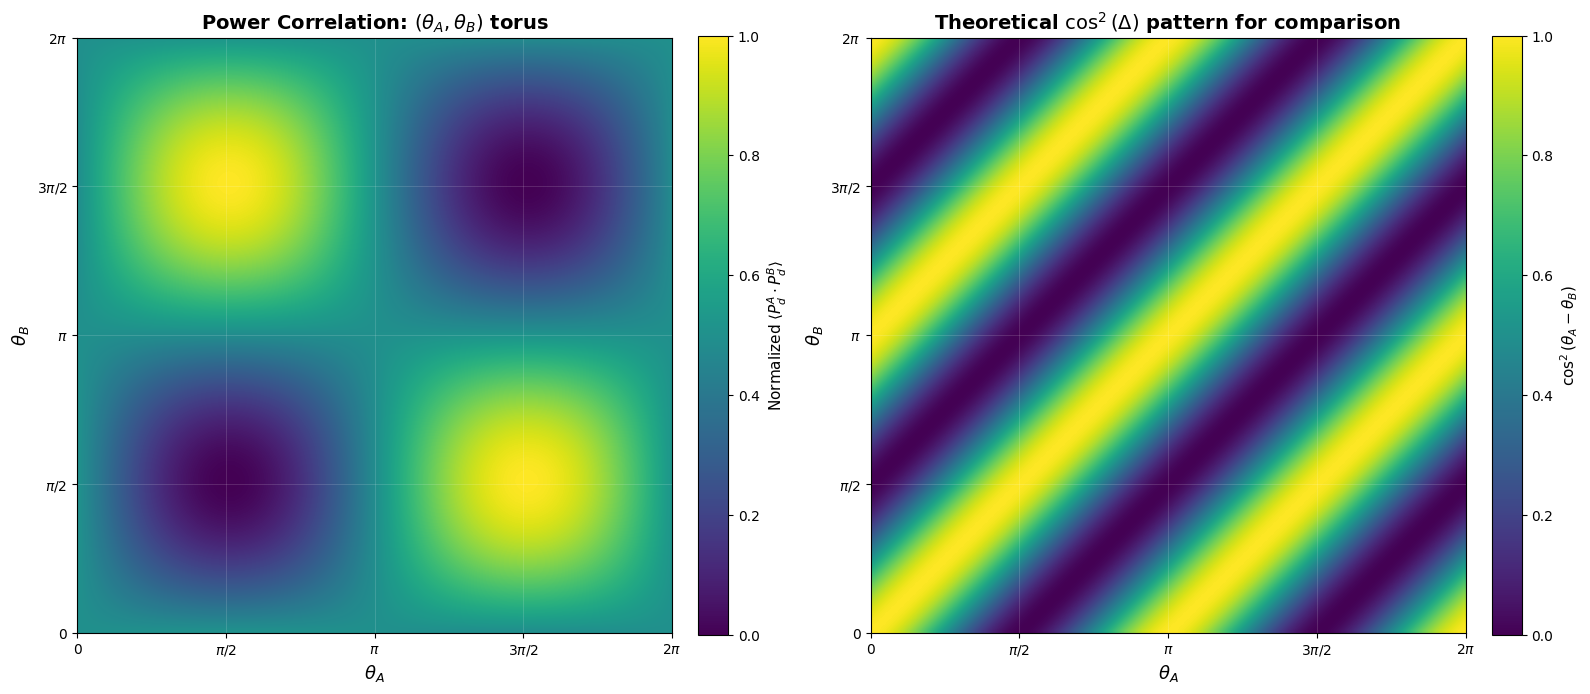

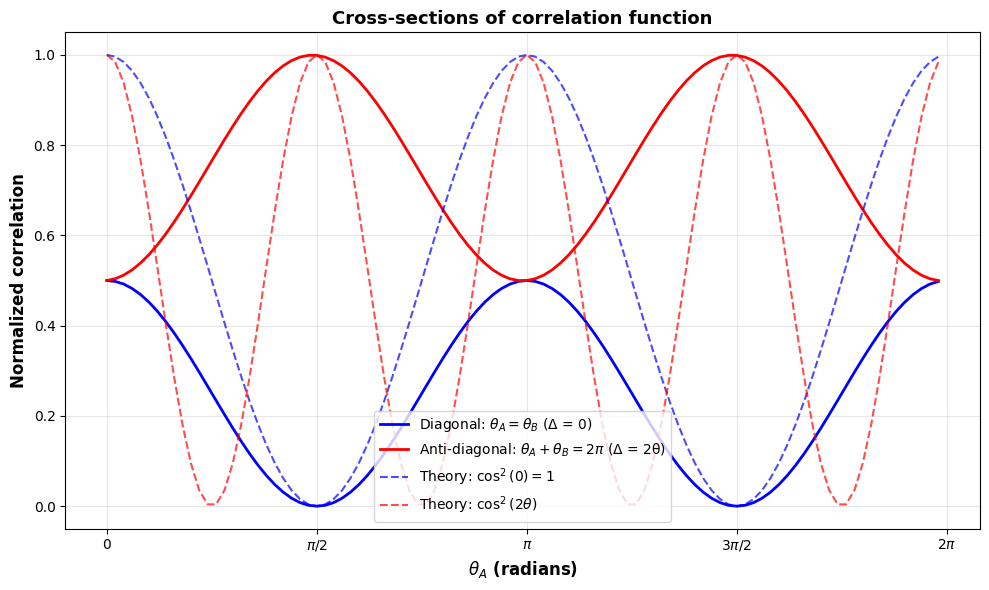

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("="*80)
print("REFINED TWO-PACKET CORRELATION (Born-rule style)")
print("="*80)

# Parameters
V_p = 391.92
f = 60
omega = 2 * np.pi * f
T = 1/f

t = np.linspace(0, 6*T, 10000)

# Voltages
V_a = V_p * np.sin(omega * t)
V_b = V_p * np.sin(omega * t - 2*np.pi/3)
V_c = V_p * np.sin(omega * t + 2*np.pi/3)

clarke = np.sqrt(2/3) * np.array([
    [1, -0.5, -0.5],
    [0, np.sqrt(3)/2, -np.sqrt(3)/2],
    [1/np.sqrt(2), 1/np.sqrt(2), 1/np.sqrt(2)]
])

def create_packet(I_pos, theta_pos, I_neg, theta_neg, t_center, sigma):
    envelope = np.exp(-((t - t_center)**2) / (2 * sigma**2))
    
    I_a_pos = I_pos * np.sin(omega * t + theta_pos)
    I_b_pos = I_pos * np.sin(omega * t + theta_pos - 2*np.pi/3)
    I_c_pos = I_pos * np.sin(omega * t + theta_pos + 2*np.pi/3)
    
    I_a_neg = I_neg * np.sin(omega * t + theta_neg)
    I_b_neg = I_neg * np.sin(omega * t + theta_neg + 2*np.pi/3)
    I_c_neg = I_neg * np.sin(omega * t + theta_neg - 2*np.pi/3)
    
    I_a = (I_a_pos + I_a_neg) * envelope
    I_b = (I_b_pos + I_b_neg) * envelope
    I_c = (I_c_pos + I_c_neg) * envelope
    
    I_abc = np.array([I_a, I_b, I_c])
    I_alphabeta0 = clarke @ I_abc
    
    return I_a, I_b, I_c, I_alphabeta0[0], I_alphabeta0[1]

def compute_dq_power(I_alpha, I_beta, theta_park):
    V_abc = np.array([V_a, V_b, V_c])
    V_alphabeta0 = clarke @ V_abc
    V_alpha = V_alphabeta0[0]
    V_beta = V_alphabeta0[1]
    
    V_d = V_alpha * np.cos(theta_park) + V_beta * np.sin(theta_park)
    V_q = -V_alpha * np.sin(theta_park) + V_beta * np.cos(theta_park)
    
    I_d = I_alpha * np.cos(theta_park) + I_beta * np.sin(theta_park)
    I_q = -I_alpha * np.sin(theta_park) + I_beta * np.cos(theta_park)
    
    P_d = V_d * I_d
    P_q = V_q * I_q
    
    return P_d, P_q

# Parameters
I_pos = 200
I_neg = 200  # 0 for pure packets
t_center_A = 2.5 * T
t_center_B = 3.5 * T
sigma = T / 8

# Grid
N = 100
theta_A_vals = np.linspace(0, 2*np.pi, N, endpoint=False)
theta_B_vals = np.linspace(0, 2*np.pi, N, endpoint=False)
TA, TB = np.meshgrid(theta_A_vals, theta_B_vals, indexing='ij')

# Compute correlation
print("Computing correlation function...")
correlation = np.zeros((N, N))

for i, theta_A in enumerate(theta_A_vals):
    if i % 20 == 0:
        print(f"  Progress: {i}/{N}")
    
    for j, theta_B in enumerate(theta_B_vals):
        # Packet A measured at angle theta_A
        _, _, _, I_alpha_A, I_beta_A = create_packet(
            I_pos, theta_A, I_neg, 0, t_center_A, sigma
        )
        P_d_A, P_q_A = compute_dq_power(I_alpha_A, I_beta_A, theta_A)
        
        # Packet B measured at angle theta_B
        _, _, _, I_alpha_B, I_beta_B = create_packet(
            I_pos, theta_B, I_neg, 0, t_center_B, sigma
        )
        P_d_B, P_q_B = compute_dq_power(I_alpha_B, I_beta_B, theta_B)
        
        # Extract power at packet centers
        idx_A = np.argmin(np.abs(t - t_center_A))
        idx_B = np.argmin(np.abs(t - t_center_B))
        
        # Use instantaneous power at peak
        power_A = P_d_A[idx_A]
        power_B = P_d_B[idx_B]
        
        # Normalized correlation
        max_power = (3/2) * V_p * I_pos
        correlation[i, j] = (power_A * power_B) / (max_power**2)

print("Done!\n")

# Normalize to [0, 1]
Delta = TA - TB
correlation_normalized = (correlation - correlation.min()) / (correlation.max() - correlation.min())

# Create plots like your example
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Actual correlation (like your texture)
ax1 = axes[0]
im1 = ax1.imshow(
    correlation_normalized.T,
    origin="lower",
    extent=(0, 2*np.pi, 0, 2*np.pi),
    interpolation="bilinear",
    aspect="equal",
    cmap='viridis'
)
ax1.set_title("Power Correlation: $(\\theta_A, \\theta_B)$ torus", 
              fontsize=14, fontweight='bold')
ax1.set_xlabel(r"$\theta_A$", fontsize=13, fontweight='bold')
ax1.set_ylabel(r"$\theta_B$", fontsize=13, fontweight='bold')
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label(r"Normalized $\langle P_d^A \cdot P_d^B \rangle$", fontsize=11)

ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
ticklabels = ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
ax1.set_xticks(ticks, ticklabels)
ax1.set_yticks(ticks, ticklabels)

# Add grid
ax1.grid(True, alpha=0.2, color='white', linewidth=0.5)

# Plot 2: Theoretical cos^2(Δ) pattern for comparison
cos2_pattern = np.cos(Delta)**2
cos2_normalized = (cos2_pattern - cos2_pattern.min()) / (cos2_pattern.max() - cos2_pattern.min())

ax2 = axes[1]
im2 = ax2.imshow(
    cos2_normalized.T,
    origin="lower",
    extent=(0, 2*np.pi, 0, 2*np.pi),
    interpolation="bilinear",
    aspect="equal",
    cmap='viridis'
)
ax2.set_title(r"Theoretical $\cos^2(\Delta)$ pattern for comparison", 
              fontsize=14, fontweight='bold')
ax2.set_xlabel(r"$\theta_A$", fontsize=13, fontweight='bold')
ax2.set_ylabel(r"$\theta_B$", fontsize=13, fontweight='bold')
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label(r"$\cos^2(\theta_A - \theta_B)$", fontsize=11)

ax2.set_xticks(ticks, ticklabels)
ax2.set_yticks(ticks, ticklabels)
ax2.grid(True, alpha=0.2, color='white', linewidth=0.5)

plt.tight_layout()
plt.savefig('born_rule_correlation.png', dpi=150, bbox_inches='tight')

# Quantitative comparison
print("="*80)
print("QUANTITATIVE ANALYSIS")
print("="*80)

# Check correlation with theoretical patterns
Delta_flat = Delta.flatten()
corr_flat = correlation_normalized.flatten()
cos2_flat = cos2_normalized.flatten()

# Also try cos^2(Delta/2) (spin singlet pattern)
cos2_half = np.cos(Delta/2)**2
cos2_half_normalized = (cos2_half - cos2_half.min()) / (cos2_half.max() - cos2_half.min())
cos2_half_flat = cos2_half_normalized.flatten()

from scipy.stats import pearsonr
r_cos2 = pearsonr(corr_flat, cos2_flat)[0]
r_cos2_half = pearsonr(corr_flat, cos2_half_flat)[0]

print(f"\nCorrelation coefficient with theoretical patterns:")
print(f"  cos²(Δ) pattern (photon polarization): r = {r_cos2:.6f}")
print(f"  cos²(Δ/2) pattern (spin singlet):      r = {r_cos2_half:.6f}")

if r_cos2 > r_cos2_half:
    print(f"\n✓ Best match: cos²(Δ) - similar to PHOTON POLARIZATION")
    print("  This is the Malus law pattern!")
else:
    print(f"\n✓ Best match: cos²(Δ/2) - similar to SPIN SINGLET")
    print("  This is the quantum entanglement pattern!")

# Extract 1D slice along diagonal and anti-diagonal
diagonal_idx = range(N)
correlation_diagonal = [correlation_normalized[i, i] for i in diagonal_idx]
correlation_antidiag = [correlation_normalized[i, N-1-i] for i in diagonal_idx]

fig2, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(theta_A_vals, correlation_diagonal, 'b-', linewidth=2, 
        label=r'Diagonal: $\theta_A = \theta_B$ (Δ = 0)')
ax.plot(theta_A_vals, correlation_antidiag, 'r-', linewidth=2, 
        label=r'Anti-diagonal: $\theta_A + \theta_B = 2\pi$ (Δ = 2θ)')
ax.plot(theta_A_vals, np.cos(theta_A_vals - theta_A_vals[0])**2, 'b--', 
        linewidth=1.5, alpha=0.7, label=r'Theory: $\cos^2(0) = 1$')
ax.plot(theta_A_vals, np.cos(2*theta_A_vals)**2, 'r--', 
        linewidth=1.5, alpha=0.7, label=r'Theory: $\cos^2(2\theta)$')

ax.set_xlabel(r'$\theta_A$ (radians)', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized correlation', fontsize=12, fontweight='bold')
ax.set_title('Cross-sections of correlation function', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(ticks, ticklabels)
plt.tight_layout()
plt.savefig('correlation_cross_sections.png', dpi=150, bbox_inches='tight')

print("\nPlots saved:")
print("  - born_rule_correlation.png")
print("  - correlation_cross_sections.png")

plt.show()